<img src="images/Cat.jpg" alt="Cat" width="120" style="float: right; margin-left: 16px; border-radius: 6px;" />

<h1 style="margin: 0 0 6px 0; line-height: 1.1;">Audiological Analysis of Speech Understanding in Noise</h1>

This notebook analyzes data from the PAHRE clinical validation study.

Notebook coded by, yours truly, Oskar Gyllenör, an enthusiastic audiologist, tester, and software engineering student.<br>
(Picture is not a representation of the author.)

## Project Goal

The goal of this project is to investigate whether speech understanding in noise becomes worse with age and high-frequency hearing loss, and whether Lombard speech appears to improve listening performance.

## Dataset Context

The dataset comes from a clinical validation study of the PAHRE test, which stands for *Prueba Auditiva de Habla en Ruido en Espanol*. PAHRE is a Spanish speech-in-noise test designed to measure how well people understand speech when background babble noise is present. <br> For Swedish readers, imagine "Folk babblar"

The study also examines the Lombard effect. This is when a speaker naturally changes their voice in noisy environments, often by increasing vocal intensity and changing speech characteristics. Something we all do without thinking about. <br>In this dataset, some test conditions use standard speech and others use Lombard speech.

The dataset contains demographic variables such as age, sex, and education level, together with hearing-related variables and speech-in-noise performance scores.


In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "text.color": "#222222",
    "grid.color": "#cccccc",
    "savefig.facecolor": "white",
})

df = pd.read_spss("test_data.sav")

df.head()

,SEX,AGE,AGEGROUP,STUDIES,DROP4kHz,SLOPECURVE,BLOCK,NLB12,NLB6,NLB3,...,NLA0,NLA3_A,NLA6_A,LA12,LA6,LA3,LA0,LA3_A,LA6_A,filter_$
0,hombre,18.0,18-49,bachillerato,NO,NORMAL,10.0,4.0,5.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Selected
1,hombre,18.0,18-49,bachillerato,NO,NORMAL,6.0,5.0,5.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Selected
2,hombre,19.0,18-49,bachillerato,NO,NORMAL,14.0,5.0,5.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Selected
3,mujer,19.0,18-49,bachillerato,NO,NORMAL,15.0,5.0,5.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Selected
4,mujer,20.0,18-49,bachillerato,NO,NORMAL,12.0,5.0,5.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Selected


## First Inspection

Before analyzing the data, I inspect the shape, column names, data types, and missing values. Choosing to do this helps me understand what kind of cleaning is needed.

In [62]:
print(f"Rows and columns: {df.shape}")
print(f"Duplicate rows: {df.duplicated().sum()}")

df.info()

Rows and columns: (144, 70)
Duplicate rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 70 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   SEX         144 non-null    category
 1   AGE         144 non-null    float64 
 2   AGEGROUP    144 non-null    category
 3   STUDIES     144 non-null    category
 4   DROP4kHz    144 non-null    category
 5   SLOPECURVE  144 non-null    category
 6   BLOCK       144 non-null    float64 
 7   NLB12       144 non-null    float64 
 8   NLB6        144 non-null    float64 
 9   NLB3        144 non-null    float64 
 10  NLB0        144 non-null    float64 
 11  NLB3_A      144 non-null    float64 
 12  NLB6_A      144 non-null    float64 
 13  PLUSNLBIN   144 non-null    float64 
 14  SRTNLBIN1   144 non-null    float64 
 15  SRTNLBIN2   144 non-null    float64 
 16  LB12        144 non-null    float64 
 17  LB6         144 non-null    float64 
 18  LB3         144

In [63]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

LOD0       144
LOD12      144
LOD3_A     144
SRTNLOD    144
PLUSLOD    144
NLOD6_A    144
NLA6_A     144
LA12       144
LA6        144
NLA12      144
NLA6       144
NLA3       144
LOD3       144
LOD6       144
NLOD6      144
NLOD3      144
NLOD0      144
NLOD3_A    144
NLOD12     144
SRTLOI     144
SUMALOI    144
LOI6_A     144
LOI3_A     144
LOI0       144
LOI3       144
LOI6       144
LOI12      144
SRTNLOI    144
PLUSLOI    144
NLOI6_A    144
NLOI3_A    144
NLOI0      144
NLOI3      144
NLOI6      144
NLOI12     144
SRTLOD     144
SUMALOD    144
LOD6_A     144
LA0        144
LA3_A      144
LA6_A      144
LA3        144
NLA0       144
NLA3_A     144
dtype: int64

In [64]:
df.describe()

,AGE,BLOCK,NLB12,NLB6,NLB3,NLB0,NLB3_A,NLB6_A,PLUSNLBIN,SRTNLBIN1,...,NLA3,NLA0,NLA3_A,NLA6_A,LA12,LA6,LA3,LA0,LA3_A,LA6_A
count,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,48.166667,7.500000,4.937500,4.618056,4.284722,3.159722,0.875000,0.020833,17.895833,2.762500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,14.700744,4.506406,0.294916,0.923633,1.168725,1.819334,1.294826,0.143325,3.348559,2.009136,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,18.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,-1.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,39.000000,4.000000,5.000000,5.000000,4.000000,2.000000,0.000000,0.000000,16.000000,1.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,46.000000,7.000000,5.000000,5.000000,5.000000,3.000000,0.000000,0.000000,18.000000,2.700000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,60.000000,11.000000,5.000000,5.000000,5.000000,5.000000,1.000000,0.000000,20.000000,3.900000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,85.000000,16.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,25.000000,10.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
df["SEX"].value_counts()

SEX
hombre    94
mujer     50
Name: count, dtype: int64

In [66]:
df.columns.tolist()

['SEX',
 'AGE',
 'AGEGROUP',
 'STUDIES',
 'DROP4kHz',
 'SLOPECURVE',
 'BLOCK',
 'NLB12',
 'NLB6',
 'NLB3',
 'NLB0',
 'NLB3_A',
 'NLB6_A',
 'PLUSNLBIN',
 'SRTNLBIN1',
 'SRTNLBIN2',
 'LB12',
 'LB6',
 'LB3',
 'LB0',
 'LB3_A',
 'LB6_A',
 'PLUSLCIN',
 'SRTLBIN1',
 'SRTLBIN2',
 'NLOD12',
 'NLOD6',
 'NLOD3',
 'NLOD0',
 'NLOD3_A',
 'NLOD6_A',
 'PLUSLOD',
 'SRTNLOD',
 'LOD12',
 'LOD6',
 'LOD3',
 'LOD0',
 'LOD3_A',
 'LOD6_A',
 'SUMALOD',
 'SRTLOD',
 'NLOI12',
 'NLOI6',
 'NLOI3',
 'NLOI0',
 'NLOI3_A',
 'NLOI6_A',
 'PLUSLOI',
 'SRTNLOI',
 'LOI12',
 'LOI6',
 'LOI3',
 'LOI0',
 'LOI3_A',
 'LOI6_A',
 'SUMALOI',
 'SRTLOI',
 'NLA12',
 'NLA6',
 'NLA3',
 'NLA0',
 'NLA3_A',
 'NLA6_A',
 'LA12',
 'LA6',
 'LA3',
 'LA0',
 'LA3_A',
 'LA6_A',
 'filter_$']

In [67]:
df["AGEGROUP"].value_counts()

AGEGROUP
18-49    86
50-59    21
60-69    21
70-79    15
>80       1
Name: count, dtype: int64

In [68]:
df["DROP4kHz"].value_counts()

DROP4kHz
NO    94
SI    50
Name: count, dtype: int64

Strangely, the file contains 144 rows and 70 columns. The article context (where I got the data from) mentions 104 participants, but this data file does not include a participant ID column. Because of this, I treat the rows as observations in this file rather than confirmed unique participants.

The row counts also add up to 144 when grouped by sex, age group, and high-frequency hearing loss status, which confirms that the notebook is reading the full file correctly. Considering the dataset file is ina strage file type (.sav) also made a test file to confirm that the libraries needed to read that file are being read properly.

## Data Cleaning

Many columns in the file are completely empty. As far as I know, this is common in clinical SPSS datasets, where files may include columns for alternative test conditions, repeated measurement templates, or even variables that were not used in the final analysis.

In this dataset, the empty columns do not contribute information to the current analysis, so I remove all columns where values are missing. This keeps the analysis focused on the demographic variables and the PAHRE speech-in-noise scores that are actually present in the file.

In [69]:
df_clean = df.dropna(axis=1, how="all").copy()

print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")

df_clean.columns.tolist()

Original shape: (144, 70)
Cleaned shape: (144, 26)


['SEX',
 'AGE',
 'AGEGROUP',
 'STUDIES',
 'DROP4kHz',
 'SLOPECURVE',
 'BLOCK',
 'NLB12',
 'NLB6',
 'NLB3',
 'NLB0',
 'NLB3_A',
 'NLB6_A',
 'PLUSNLBIN',
 'SRTNLBIN1',
 'SRTNLBIN2',
 'LB12',
 'LB6',
 'LB3',
 'LB0',
 'LB3_A',
 'LB6_A',
 'PLUSLCIN',
 'SRTLBIN1',
 'SRTLBIN2',
 'filter_$']

## Variables Used in This Analysis

To keep the analysis focused, I chose to use a smaller set of variables connected to the project goal:

- `AGE`: participant age, duh
- `AGEGROUP`: age group, 18-49, 50-59, 60-69, 70-70, >80
- `SEX`: participant sex
- `STUDIES`: education level
- `DROP4kHz`: whether the participant has a high-frequency drop-off around 4000 Hz
- `SRTNLBIN1`: speech reception threshold in the non-Lombard condition. Lower values mean better speech understanding.
- `SRTLBIN1`: speech reception threshold in the Lombard condition. Lower values mean better speech understanding.
- `PLUSNLBIN`: total score in the non-Lombard condition. Higher values mean better performance.
- `PLUSLCIN`: total score in the Lombard condition. Higher values mean better performance.


In [70]:
analysis_columns = [
    "AGE",
    "AGEGROUP",
    "SEX",
    "STUDIES",
    "DROP4kHz",
    "SRTNLBIN1",
    "SRTLBIN1",
    "PLUSNLBIN",
    "PLUSLCIN",
]

analysis_df = df_clean[analysis_columns].copy()

analysis_df.head()

,AGE,AGEGROUP,SEX,STUDIES,DROP4kHz,SRTNLBIN1,SRTLBIN1,PLUSNLBIN,PLUSLCIN
0,18.0,18-49,hombre,bachillerato,NO,2.7,0.3,18.0,22.0
1,18.0,18-49,hombre,bachillerato,NO,3.9,-3.9,16.0,29.0
2,19.0,18-49,hombre,bachillerato,NO,4.5,-0.9,15.0,24.0
3,19.0,18-49,mujer,bachillerato,NO,3.9,-1.5,16.0,25.0
4,20.0,18-49,mujer,bachillerato,NO,0.9,-2.7,21.0,27.0


## Pandas Grouping and Filtering

Before visualizing the data, I use pandas to compare groups that are relevant to the project goal. I look at age groups and high-frequency hearing loss because both are expected to relate to speech understanding in noise.

In [71]:
agegroup_summary = (
    analysis_df
    .groupby("AGEGROUP", observed=True)
    .agg(
        observations=("AGE", "count"),
        mean_age=("AGE", "mean"),
        mean_srt_non_lombard=("SRTNLBIN1", "mean"),
        mean_srt_lombard=("SRTLBIN1", "mean"),
        mean_score_non_lombard=("PLUSNLBIN", "mean"),
        mean_score_lombard=("PLUSLCIN", "mean"),
    )
)

agegroup_summary

,observations,mean_age,mean_srt_non_lombard,mean_srt_lombard,mean_score_non_lombard,mean_score_lombard
AGEGROUP,,,,,,
18-49,86,38.406977,2.106977,-2.965116,18.988372,27.441860
50-59,21,52.952381,2.785714,-2.471429,17.857143,26.619048
60-69,21,63.761905,3.928571,-2.271429,15.952381,26.285714
70-79,15,73.133333,4.460000,-0.780000,15.066667,23.800000
>80,1,85.000000,8.700000,-0.300000,8.000000,23.000000


In [72]:
drop4khz_yes = analysis_df[analysis_df["DROP4kHz"] == "SI"]
drop4khz_no = analysis_df[analysis_df["DROP4kHz"] == "NO"]

print(f"Rows with high-frequency drop-off: {len(drop4khz_yes)}")
print(f"Rows without high-frequency drop-off: {len(drop4khz_no)}")

Rows with high-frequency drop-off: 50
Rows without high-frequency drop-off: 94


In [73]:
drop4khz_summary = (
    analysis_df
    .groupby("DROP4kHz", observed=True)
    .agg(
        observations=("AGE", "count"),
        mean_age=("AGE", "mean"),
        mean_srt_non_lombard=("SRTNLBIN1", "mean"),
        mean_srt_lombard=("SRTLBIN1", "mean"),
    )
)

drop4khz_summary

,observations,mean_age,mean_srt_non_lombard,mean_srt_lombard
DROP4kHz,,,,
NO,94,42.670213,2.368085,-2.917021
SI,50,58.500000,3.504000,-1.848000


## NumPy Calculations

NumPy calculations are essential. Here I convert the relevant numeric columns to arrays and use vectorized calculations for the paired Lombard improvement and the relationship between age and non-Lombard SRT.

In [74]:
srt_non_lombard = analysis_df["SRTNLBIN1"].to_numpy()
srt_lombard = analysis_df["SRTLBIN1"].to_numpy()
age_values = analysis_df["AGE"].to_numpy()

lombard_improvement = srt_non_lombard - srt_lombard
age_srt_correlation = np.corrcoef(age_values, srt_non_lombard)[0, 1]

numpy_summary = pd.Series({
    "mean_lombard_improvement_db_snr": np.mean(lombard_improvement),
    "median_lombard_improvement_db_snr": np.median(lombard_improvement),
    "age_srt_correlation": age_srt_correlation,
    "largest_lombard_improvement_db_snr": np.max(lombard_improvement),
    "smallest_lombard_improvement_db_snr": np.min(lombard_improvement),
})

numpy_summary.round(2)

mean_lombard_improvement_db_snr         5.31
median_lombard_improvement_db_snr       5.40
age_srt_correlation                     0.44
largest_lombard_improvement_db_snr     12.00
smallest_lombard_improvement_db_snr     0.60
dtype: float64

The NumPy calculations give two useful checks before plotting: the Lombard condition can be compared row by row because both SRT columns are paired measurements, and the age-SRT correlation gives a compact numeric summary of the age trend. I still use visualizations afterward because a single statistic can hide group imbalance and spread.

## Translated Terms

Some category labels in the dataset are written in Spanish. I keep the original values in the dataframe, but translate the most important terms here so the analysis is easier to follow. While it would be more fun to keep it in Spanish I do care about whoever reads this.

| Original term  | English meaning |
|----------------|---|
| hombre         | man |
| mujer          | woman |
| PRIMARIA       | primary school |
| ESO            | compulsory secondary education |
| Bachillerato   | upper secondary / high school track |
| FP MEDIO       | intermediate vocational training |
| FP SUPERIOR    | higher vocational training |
| UNIVERSITARIOS | university studies |
| MASTER         | master's degree |
| DOCTORADO      | doctorate / PhD |
| SI             | yes |
| NO             | no |

I do not replace the original values in the dataframe because keeping the source labels makes it easier to trace the analysis back to the original dataset.

## Visualization 1: Age Distribution

Question: What does the age distribution of the observations look like?

This matters because age is one of the main factors being investigated in relation to speech understanding in noise. <br>
Mostly due to the presence of Presbyacusis. What we find is that there is not a proportional amount of observations in each age group. Most are between 40 and 50 years old and only one is older than 80.

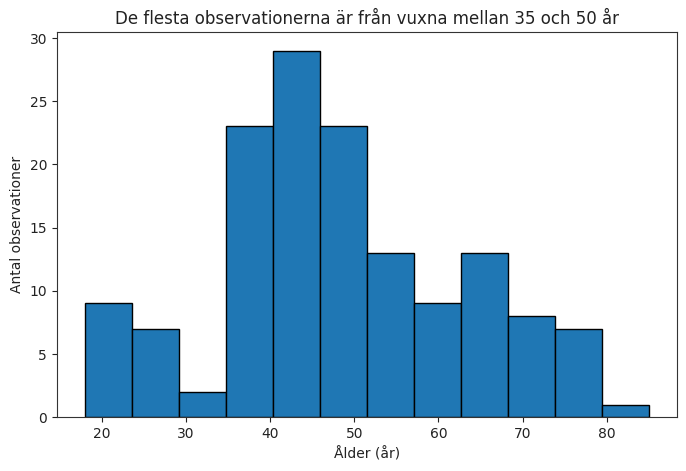

In [75]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(analysis_df["AGE"], bins=12, edgecolor="black")

ax.set_title("De flesta observationerna är från vuxna mellan 35 och 50 år")
ax.set_xlabel("Ålder (år)")
ax.set_ylabel("Antal observationer")

plt.show()

## Visualization 2: Speech Understanding by Age Group

Question: Do older test subjects need a higher signal-to-noise ratio to understand speech in noise?

I use a bar chart because the main comparison here is the average SRT for each age group.

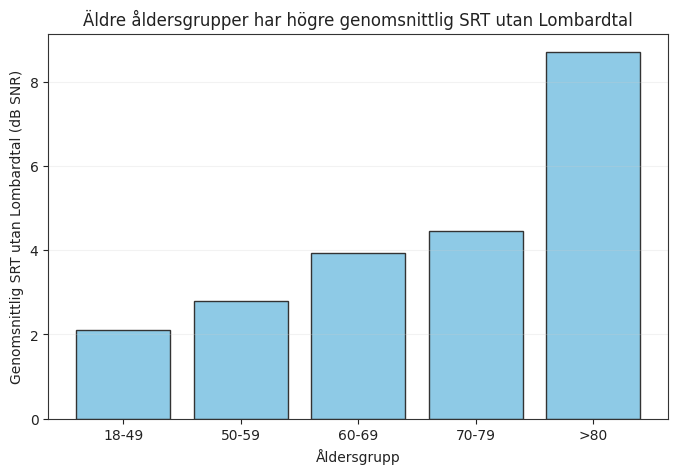

In [76]:
age_order = ["18-49", "50-59", "60-69", "70-79", ">80"]
age_means = analysis_df.groupby("AGEGROUP", observed=True)["SRTNLBIN1"].mean().reindex(age_order)

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(age_means.index, age_means.values, color="#8ecae6", edgecolor="#333333")

ax.set_title("Äldre åldersgrupper har högre genomsnittlig SRT utan Lombardtal")
ax.set_xlabel("Åldersgrupp")
ax.set_ylabel("Genomsnittlig SRT utan Lombardtal (dB SNR)")
ax.grid(axis="y", alpha=0.25)

plt.show()

The average SRT generally increases across older age groups. Since higher SRT means worse speech understanding in noise, this supports the idea that speech understanding becomes harder with age. The `>80` group should be interpreted carefully because it has a singular observation, regardless the massive difference between 70-79 and >80 may suggest an exponential hearing decline due to Presbyacusis.

## Visualization 3: High-Frequency Drop-Off and SRT

Question: Do observations with high-frequency hearing loss perform worse on the speech-in-noise test?

I use a violin plot with jittered points because `DROP4kHz` has two groups, and I want to compare both the distribution and the individual observations instead of only comparing averages.

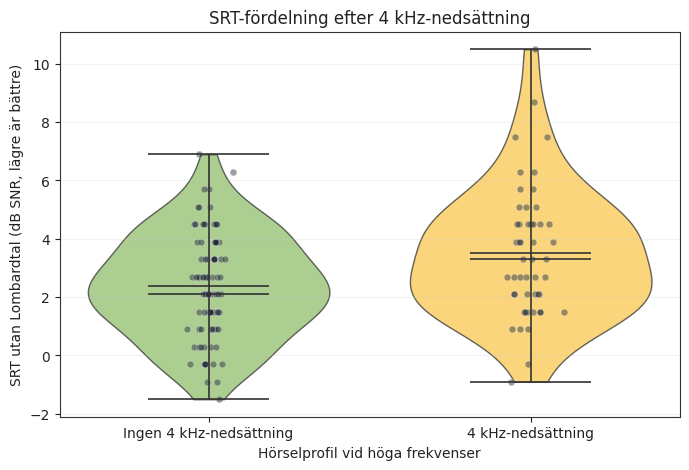

In [77]:
drop_order = ["NO", "SI"]
drop_labels = ["Ingen 4 kHz-nedsättning", "4 kHz-nedsättning"]
drop_groups = [
    analysis_df.loc[analysis_df["DROP4kHz"] == value, "SRTNLBIN1"].dropna()
    for value in drop_order
]

fig, ax = plt.subplots(figsize=(8, 5))

violin = ax.violinplot(drop_groups, showmeans=True, showmedians=True, widths=0.75)

for body, color in zip(violin["bodies"], ["#90be6d", "#f9c74f"]):
    body.set_facecolor(color)
    body.set_edgecolor("#333333")
    body.set_alpha(0.75)

for key in ["cmeans", "cmedians", "cbars", "cmins", "cmaxes"]:
    violin[key].set_color("#333333")
    violin[key].set_linewidth(1.2)

rng = np.random.default_rng(42)
for position, values in enumerate(drop_groups, start=1):
    jitter = rng.normal(0, 0.035, size=len(values))
    ax.scatter(
        np.full(len(values), position) + jitter,
        values,
        color="#1f2937",
        alpha=0.45,
        s=24,
        edgecolor="white",
        linewidth=0.4,
    )

ax.set_xticks([1, 2])
ax.set_xticklabels(drop_labels)
ax.set_title("SRT-fördelning efter 4 kHz-nedsättning")
ax.set_xlabel("Hörselprofil vid höga frekvenser")
ax.set_ylabel("SRT utan Lombardtal (dB SNR, lägre är bättre)")
ax.grid(axis="y", alpha=0.25)

plt.show()

The group marked `SI` for `DROP4kHz` has a higher average non-Lombard SRT than the group marked `NO`. Since higher SRT means more signal is needed over the noise, this suggests poorer speech understanding in noise for the high-frequency drop-off group. While this may come off as obvious it is still an important note to take.

## Visualization 4: Non-Lombard vs Lombard SRT

Question: Does Lombard speech appear to improve speech understanding in noise?

I use a paired comparison because each row has both a non-Lombard and a Lombard SRT value. The faint lines show individual observations, and the large markers show the mean for each condition.

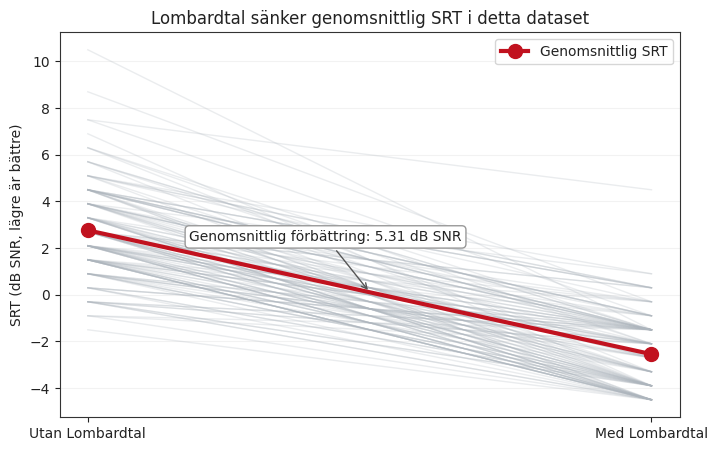

In [78]:
condition_means = analysis_df[["SRTNLBIN1", "SRTLBIN1"]].mean()
mean_improvement = condition_means["SRTNLBIN1"] - condition_means["SRTLBIN1"]

fig, ax = plt.subplots(figsize=(8, 5))

for _, row in analysis_df[["SRTNLBIN1", "SRTLBIN1"]].dropna().iterrows():
    ax.plot([0, 1], [row["SRTNLBIN1"], row["SRTLBIN1"]], color="#adb5bd", alpha=0.25, linewidth=1)

ax.plot(
    [0, 1],
    [condition_means["SRTNLBIN1"], condition_means["SRTLBIN1"]],
    color="#c1121f",
    marker="o",
    markersize=10,
    linewidth=3,
    label="Genomsnittlig SRT",
)

ax.annotate(
    f"Genomsnittlig förbättring: {mean_improvement:.2f} dB SNR",
    xy=(0.5, condition_means.mean()),
    xytext=(0.18, condition_means.mean() + 2.2),
    fontsize=10,
    bbox={"boxstyle": "round,pad=0.3", "fc": "white", "ec": "#999999"},
    arrowprops={"arrowstyle": "->", "color": "#555555"},
)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Utan Lombardtal", "Med Lombardtal"])
ax.set_title("Lombardtal sänker genomsnittlig SRT i detta dataset")
ax.set_ylabel("SRT (dB SNR, lägre är bättre)")
ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.show()

The paired comparison shows that the Lombard condition has a lower average SRT than the non-Lombard condition. In practical terms, participants needed less favorable signal-to-noise conditions when listening to Lombard speech, which supports the idea of a Lombard benefit.

## Boxplot: SRT Spread by Listening Condition

A boxplot is useful here because it shows the median, spread, and possible outliers for the SRT scores in the non-Lombard and Lombard conditions.

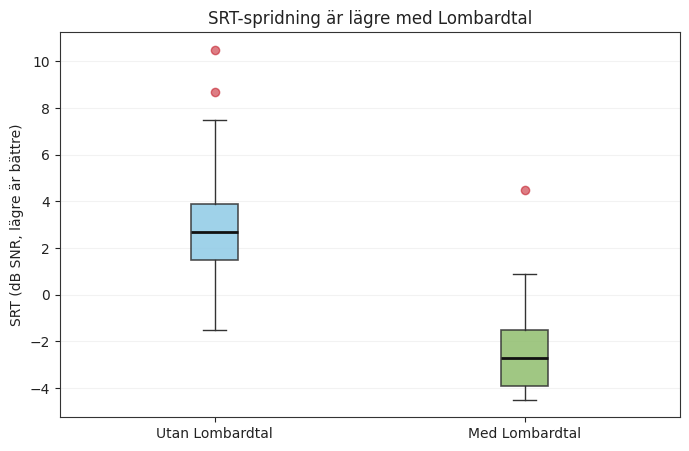

In [79]:
srt_boxplot_data = [
    analysis_df["SRTNLBIN1"].dropna(),
    analysis_df["SRTLBIN1"].dropna(),
]

fig, ax = plt.subplots(figsize=(8, 5))

box = ax.boxplot(
    srt_boxplot_data,
    tick_labels=["Utan Lombardtal", "Med Lombardtal"],
    patch_artist=True,
    medianprops={"color": "#111111", "linewidth": 2},
    boxprops={"edgecolor": "#333333", "linewidth": 1.2},
    whiskerprops={"color": "#333333"},
    capprops={"color": "#333333"},
    flierprops={"marker": "o", "markerfacecolor": "#c1121f", "markeredgecolor": "#c1121f", "alpha": 0.55},
)

for patch, color in zip(box["boxes"], ["#8ecae6", "#90be6d"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

ax.set_title("SRT-spridning är lägre med Lombardtal")
ax.set_ylabel("SRT (dB SNR, lägre är bättre)")
ax.grid(axis="y", alpha=0.25)

plt.show()

## Visualization 5: Age and SRT as Continuous Variables

Question: Is the age relationship still visible when age is treated as a continuous number instead of grouped categories?

I use a scatter plot with a simple trend line because this shows individual observations and the overall direction at the same time.

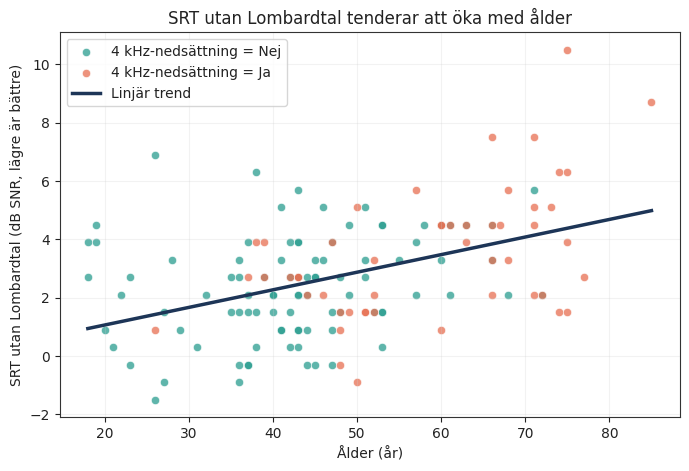

In [80]:
x = analysis_df["AGE"].to_numpy()
y = analysis_df["SRTNLBIN1"].to_numpy()
slope, intercept = np.polyfit(x, y, 1)
trend_x = np.linspace(x.min(), x.max(), 100)
trend_y = slope * trend_x + intercept

fig, ax = plt.subplots(figsize=(8, 5))

for value, label, color in [("NO", "Nej", "#2a9d8f"), ("SI", "Ja", "#e76f51")]:
    subset = analysis_df[analysis_df["DROP4kHz"] == value]
    ax.scatter(
        subset["AGE"],
        subset["SRTNLBIN1"],
        label=f"4 kHz-nedsättning = {label}",
        color=color,
        alpha=0.75,
        edgecolor="white",
        linewidth=0.6,
    )

ax.plot(trend_x, trend_y, color="#1d3557", linewidth=2.5, label="Linjär trend")

ax.set_title("SRT utan Lombardtal tenderar att öka med ålder")
ax.set_xlabel("Ålder (år)")
ax.set_ylabel("SRT utan Lombardtal (dB SNR, lägre är bättre)")
ax.grid(alpha=0.25)
ax.legend()

plt.show()

The scatter plot shows the same general direction as the age-group comparison: older observations tend to have higher non-Lombard SRT values. The points are still spread out, so age is relevant, but it is not the only factor in speech understanding in noise.

 ## Reflection and Conclusion

 **Patterns Found:**
 The analysis indicates that both increased age and high-frequency hearing loss (4 kHz drop-off) are associated with poorer speech understanding in noise (requiring a higher SRT). Additionally, Lombard speech appears to consistently improve listening performance, as demonstrated by the lower SRT scores compared to the non-Lombard condition.

 **What Cannot Be Concluded:**
 While the data is clear and the findings anecdotaly fit perfect we cannot establish causation with a sample size of 100. Especially considering that there are many factors that influence hearing, all from cognitive load to physical health, and individual differences in speech processing. More data needed!